In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/ecommerce_sales.csv")
df.head()

,OrderID,OrderDate,CustomerID,Gender,Age,Product,Category,Quantity,Price,Region,PaymentMethod
0,1001,2023-01-05,C001,Female,28,Laptop,Electronics,1,55000,South,Credit Card
1,1002,2023-01-07,C002,Male,35,T-Shirt,Clothing,3,1200,West,UPI
2,1003,2023-01-10,C003,Female,42,Rice Bag,Groceries,5,900,North,Cash
3,1004,2023-02-02,C001,Female,28,Mobile,Electronics,1,30000,South,Debit Card
4,1005,2023-02-10,C004,Male,23,Jeans,Clothing,2,2500,East,Credit Card


In [10]:
df.shape

(15, 11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   OrderID        15 non-null     int64 
 1   OrderDate      15 non-null     object
 2   CustomerID     15 non-null     object
 3   Gender         15 non-null     object
 4   Age            15 non-null     int64 
 5   Product        15 non-null     object
 6   Category       15 non-null     object
 7   Quantity       15 non-null     int64 
 8   Price          15 non-null     int64 
 9   Region         15 non-null     object
 10  PaymentMethod  15 non-null     object
dtypes: int64(4), object(7)
memory usage: 1.4+ KB


In [12]:
df.describe()

,OrderID,Age,Quantity,Price
count,15.000000,15.000000,15.000000,15.000000
mean,1008.000000,33.666667,2.800000,17743.333333
std,4.472136,6.629659,2.455315,23274.763054
min,1001.000000,23.000000,1.000000,450.000000
25%,1004.500000,28.500000,1.000000,1050.000000
50%,1008.000000,33.000000,2.000000,2500.000000
75%,1011.500000,39.500000,3.500000,35000.000000
max,1015.000000,45.000000,10.000000,65000.000000


In [13]:
df.isnull().sum()

OrderID          0
OrderDate        0
CustomerID       0
Gender           0
Age              0
Product          0
Category         0
Quantity         0
Price            0
Region           0
PaymentMethod    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['OrderDate']= pd.to_datetime(df['OrderDate'])

In [16]:
df.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        15 non-null     int64         
 1   OrderDate      15 non-null     datetime64[ns]
 2   CustomerID     15 non-null     object        
 3   Gender         15 non-null     object        
 4   Age            15 non-null     int64         
 5   Product        15 non-null     object        
 6   Category       15 non-null     object        
 7   Quantity       15 non-null     int64         
 8   Price          15 non-null     int64         
 9   Region         15 non-null     object        
 10  PaymentMethod  15 non-null     object        
dtypes: datetime64[ns](1), int64(4), object(6)
memory usage: 1.4+ KB


In [20]:
df['Total Revenue'] = df['Quantity'] * df['Price']


In [21]:
df.head()

,OrderID,OrderDate,CustomerID,Gender,Age,Product,Category,Quantity,Price,Region,PaymentMethod,Total Revenue
0,1001,2023-01-05,C001,Female,28,Laptop,Electronics,1,55000,South,Credit Card,55000
1,1002,2023-01-07,C002,Male,35,T-Shirt,Clothing,3,1200,West,UPI,3600
2,1003,2023-01-10,C003,Female,42,Rice Bag,Groceries,5,900,North,Cash,4500
3,1004,2023-02-02,C001,Female,28,Mobile,Electronics,1,30000,South,Debit Card,30000
4,1005,2023-02-10,C004,Male,23,Jeans,Clothing,2,2500,East,Credit Card,5000


In [23]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'Gender', 'Age', 'Product',
       'Category', 'Quantity', 'Price', 'Region', 'PaymentMethod',
       'Total Revenue'],
      dtype='object')

In [24]:
df['month'] = df['OrderDate'].dt.month

In [25]:
df['OrderDate'].dt.month

0     1
1     1
2     1
3     2
4     2
5     2
6     3
7     3
8     3
9     4
10    4
11    4
12    5
13    5
14    5
Name: OrderDate, dtype: int32

In [28]:
df['year'] = df['OrderDate'].dt.year

In [29]:
df.head()

,OrderID,OrderDate,CustomerID,Gender,Age,Product,Category,Quantity,Price,Region,PaymentMethod,Total Revenue,month,year
0,1001,2023-01-05,C001,Female,28,Laptop,Electronics,1,55000,South,Credit Card,55000,1,2023
1,1002,2023-01-07,C002,Male,35,T-Shirt,Clothing,3,1200,West,UPI,3600,1,2023
2,1003,2023-01-10,C003,Female,42,Rice Bag,Groceries,5,900,North,Cash,4500,1,2023
3,1004,2023-02-02,C001,Female,28,Mobile,Electronics,1,30000,South,Debit Card,30000,2,2023
4,1005,2023-02-10,C004,Male,23,Jeans,Clothing,2,2500,East,Credit Card,5000,2,2023


In [30]:
df.groupby('month')['Total Revenue'].sum()

month
1    63100
2    37400
3    48500
4    76000
5    66600
Name: Total Revenue, dtype: int64

In [33]:
df.groupby('year')['Total Revenue'].sum()

year
2023    291600
Name: Total Revenue, dtype: int64

In [34]:
df['OrderDate'].dt.day_name()

0      Thursday
1      Saturday
2       Tuesday
3      Thursday
4        Friday
5      Saturday
6     Wednesday
7     Wednesday
8        Monday
9     Wednesday
10    Wednesday
11      Tuesday
12      Tuesday
13    Wednesday
14       Monday
Name: OrderDate, dtype: object

In [39]:
df['dayname'] = df['OrderDate'].dt.day_name()


In [40]:
df.groupby('dayname')['Total Revenue'].sum()

dayname
Friday         5000
Monday        19000
Saturday       6000
Thursday      85000
Tuesday       59500
Wednesday    117100
Name: Total Revenue, dtype: int64

In [42]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df.groupby('dayname')['Total Revenue'].sum().reindex(order)

dayname
Monday        19000.0
Tuesday       59500.0
Wednesday    117100.0
Thursday      85000.0
Friday         5000.0
Saturday       6000.0
Sunday            NaN
Name: Total Revenue, dtype: float64

In [44]:
df.groupby('dayname')['Total Revenue'].sum().reindex(order).fillna(0)

dayname
Monday        19000.0
Tuesday       59500.0
Wednesday    117100.0
Thursday      85000.0
Friday         5000.0
Saturday       6000.0
Sunday            0.0
Name: Total Revenue, dtype: float64

In [47]:
df.groupby('Category')['Total Revenue'].sum().sort_values(ascending=False)

Category
Electronics    202000
Furniture       55000
Clothing        15600
Beauty          10000
Groceries        9000
Name: Total Revenue, dtype: int64

In [48]:
df.groupby('Category')['Total Revenue'].sum().sort_values(ascending=False).head(5)

Category
Electronics    202000
Furniture       55000
Clothing        15600
Beauty          10000
Groceries        9000
Name: Total Revenue, dtype: int64

In [58]:
category_revenue = df.groupby('Category')['Total Revenue'] .sum().sort_values(ascending=False)


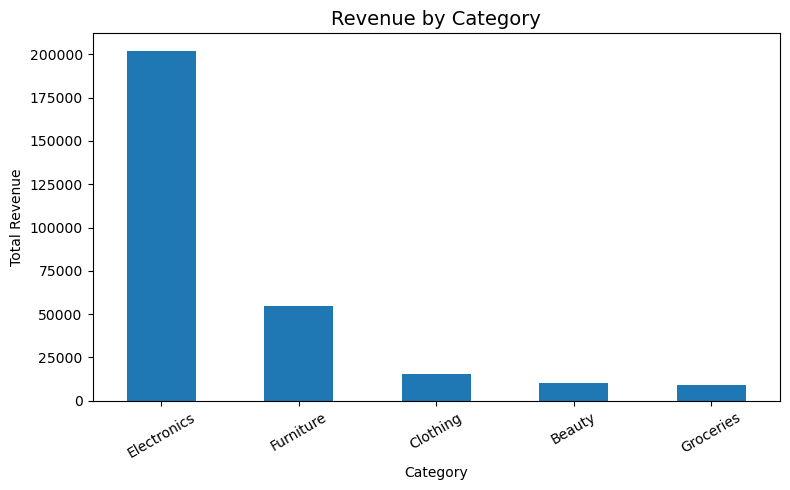

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')

plt.title("Revenue by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

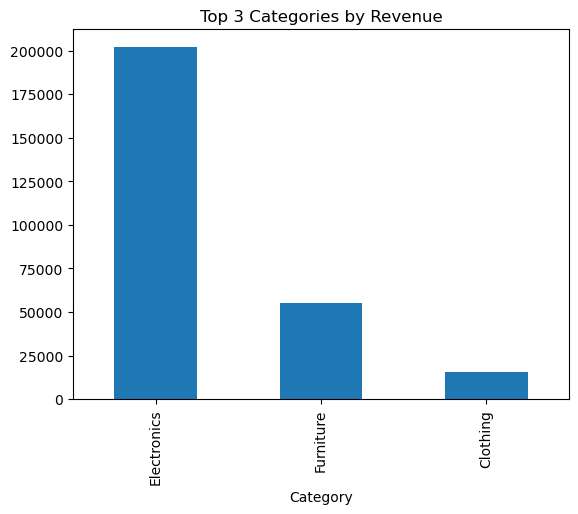

In [64]:
top3 = category_revenue.head(3)
top3.plot(kind='bar')
plt.title("Top 3 Categories by Revenue")
plt.show()

In [67]:
percentage = (top3 / category_revenue.sum()) * 100


In [68]:
import pandas as pd

top3_df = pd.DataFrame({
    'Revenue': top3,
    'Percentage (%)': (top3 / category_revenue.sum()) * 100
})

top3_df

,Revenue,Percentage (%)
Category,,
Electronics,202000,69.272977
Furniture,55000,18.861454
Clothing,15600,5.349794


In [69]:
df['CustomerID'].value_counts()

CustomerID
C001    2
C003    2
C002    1
C004    1
C005    1
C006    1
C007    1
C008    1
C009    1
C010    1
C011    1
C012    1
C013    1
Name: count, dtype: int64

In [70]:
df['CustomerID'].nunique() 

13

In [78]:
customer_orders = df['CustomerID'].value_counts()

customers_morethanonce = customer_orders[customer_orders > 1]
customers_morethanonce

CustomerID
C001    2
C003    2
Name: count, dtype: int64

In [79]:
len(customers_morethanonce)

2

In [80]:
repeat_percentage = (len(customers_morethanonce) / df['CustomerID'].nunique()) * 100
repeat_percentage

15.384615384615385

In [82]:
customer_revenue = df.groupby('CustomerID')['Total Revenue'].sum().sort_values(ascending=False)
customer_revenue

CustomerID
C001    85000
C009    65000
C011    48000
C006    40000
C013    15000
C003     9000
C010     7000
C004     5000
C007     4000
C008     4000
C002     3600
C012     3600
C005     2400
Name: Total Revenue, dtype: int64

In [83]:
customer_revenue.head(1)

CustomerID
C001    85000
Name: Total Revenue, dtype: int64

In [85]:
df.groupby('CustomerID')['Total Revenue'].mean().sort_values(ascending=False)

CustomerID
C009    65000.0
C011    48000.0
C001    42500.0
C006    40000.0
C013    15000.0
C010     7000.0
C004     5000.0
C003     4500.0
C007     4000.0
C008     4000.0
C002     3600.0
C012     3600.0
C005     2400.0
Name: Total Revenue, dtype: float64

In [90]:
bins = [20, 30, 40, 50]
labels = ['20-30', '30-40', '40-50']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df.groupby('AgeGroup')['Total Revenue'].sum()

C:\Users\hp\AppData\Local\Temp\ipykernel_19216\1607941788.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Total Revenue'].sum()


AgeGroup
20-30    104600
30-40    123000
40-50     64000
Name: Total Revenue, dtype: int64

In [92]:
total_revenue = df['Total Revenue'].sum()
total_orders = df['OrderID'].nunique()
avg_order_value = total_revenue / total_orders
total_customers = df['CustomerID'].nunique()